In [18]:
import os
import sys
sys.path.insert(0, '../..')
import numpy as np
import matplotlib.pyplot as plt
import mssfp
import deepssfp
import deepssfp.recon

print(mssfp.__version__)

0.0.5


In [19]:
def rsos(input):
    ''' Computes root sum of squares '''
    import math
    return np.sqrt(np.sum(np.square(np.abs(input)) / (input.shape[3]), axis = 3))

In [20]:
mode = deepssfp.DataMode.SyntheticBanding.value
model_name = "block_phantom"
model_dir = "D:/DeepSSFP/"
path = os.path.join(model_dir, f"{model_name}_{mode.lower().replace(':', '_')}")
ds_path = os.path.join(model_dir, f"{model_name}_dataset.npy")
print(path, ds_path)

D:/DeepSSFP/block_phantom_syntheticbanding D:/DeepSSFP/block_phantom_dataset.npy


Generating phantom...
Generating SSFP dataset...
Dataset complete.
Dataset shape: (1, 128, 128, 4)
Using same scaler for SyntheticBanding mode
0.010327115281449301 0.1847012457153848 0.010327115281449301 0.1847012457153848
Selected indices: [0]
Figure size: (4, 2)


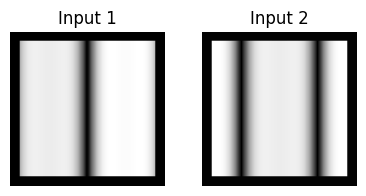

(1, 128, 128, 4) (1, 128, 128, 4)


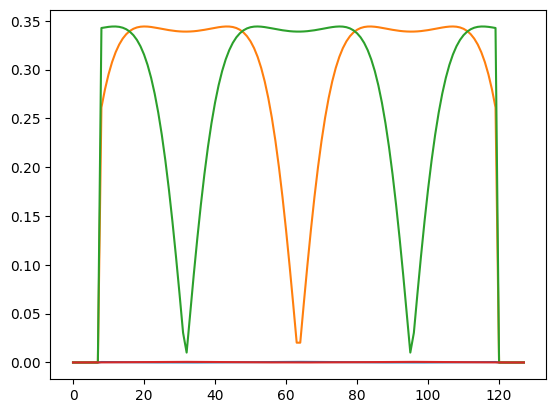

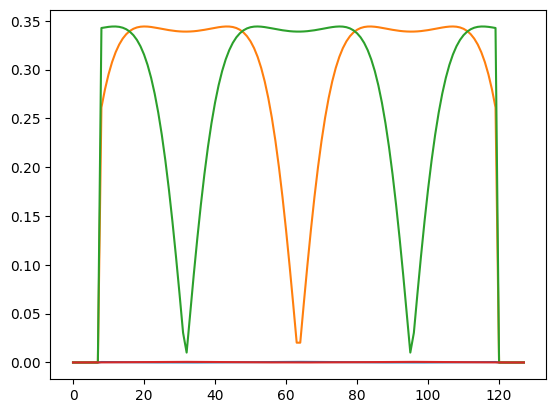

In [35]:
slices = 1
dataset = mssfp.generate_ssfp_dataset(phantom_type='block', slices=slices, shape=128, ids=[1],
                                        npcs=4, f=0, alpha=np.deg2rad(60), sigma=0.0, data_indices=[(0, 2), (120,180)], 
                                        useRotate=False, useDeform=False)

data = dataset['M']
ds = deepssfp.dataset.Dataset(mode, input_data=data)
print(ds.inputScaler.mean, ds.inputScaler.std, ds.outputScaler.mean, ds.outputScaler.std)

deepssfp.visualize_images(
    input_images=ds.x_test
)


print(ds.x.shape, ds.x_test.shape)
plt.plot(np.abs((ds.x[0,20,:,:])))
plt.show()

plt.plot(np.abs((ds.inputScaler.inverse_transform(ds.x_test[0,20,:,:]))))
plt.show()

(1, 128, 128)
Selected indices: [0]
Figure size: (10, 2)


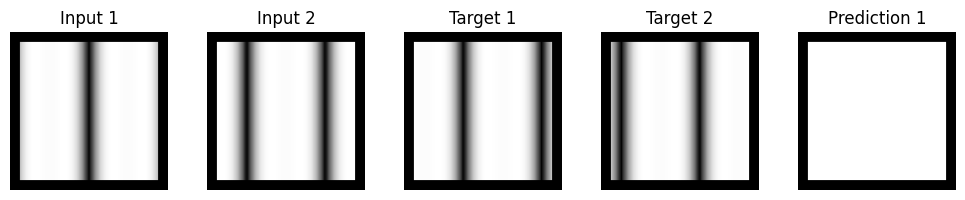

In [42]:
target_ds = deepssfp.combine_synthetic_banding_datasets(ds.x_test, ds.y_test)
target_ds = ds.inputScaler.inverse_transform(target_ds)
target_ds = deepssfp.from_pairs_to_complex(target_ds)
target = deepssfp.recon.gs_recon_3d(target_ds)
print(target.shape)

combine = np.concatenate([ds.x_test, ds.y_test], axis=3)
target2 = rsos(ds.inputScaler.inverse_transform(combine))

deepssfp.visualize_images(
    input_images=ds.inputScaler.inverse_transform(ds.x_test),
    target_images=ds.inputScaler.inverse_transform(ds.y_test),
    predicted_images=target,
)


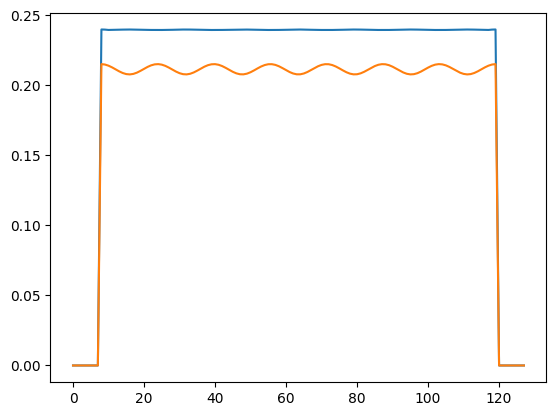

0.23972323944144322
(1, 128, 128, 4)


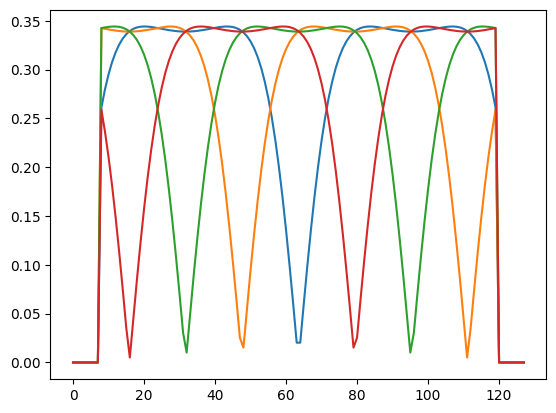

In [37]:
plt.plot(np.abs(target[0,20,:]))
plt.plot(np.abs(target2[0,20,:]))
plt.show()
print(np.max(np.abs(target)))


print(target_ds.shape)
plt.plot(np.abs(target_ds[0,20,:]))
plt.show()

In [38]:
mode = deepssfp.DataMode.BandRemoval4.value

slices = 1
dataset2 = mssfp.generate_ssfp_dataset(phantom_type='block', slices=slices, shape=128, ids=[1],
                                        npcs=4, f=0, alpha=np.deg2rad(60), sigma=0.0, data_indices=[(0, 2), (120,180)], 
                                        useRotate=False, useDeform=False)

data2 = dataset2['M']
ds2 = deepssfp.dataset.Dataset(mode, input_data=data2)
print(ds.inputScaler.mean, ds.inputScaler.std, ds.outputScaler.mean, ds.outputScaler.std)
print(ds2.inputScaler.mean, ds2.inputScaler.std, ds2.outputScaler.mean, ds2.outputScaler.std)

Generating phantom...
Generating SSFP dataset...
Dataset complete.
Dataset shape: (1, 128, 128, 4)
0.010327115281449301 0.1847012457153848 0.010327115281449301 0.1847012457153848
0.010327115281449304 0.18470124571538474 0.012020117177154288 0.1477035820230624


Selected indices: [0]
Figure size: (10, 2)


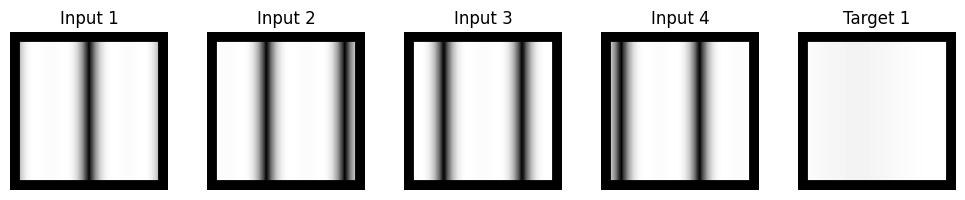

In [41]:
deepssfp.visualize_images(
    input_images=ds.inputScaler.inverse_transform(ds2.x_test),
    target_images=ds.inputScaler.inverse_transform(ds2.y_test),
)

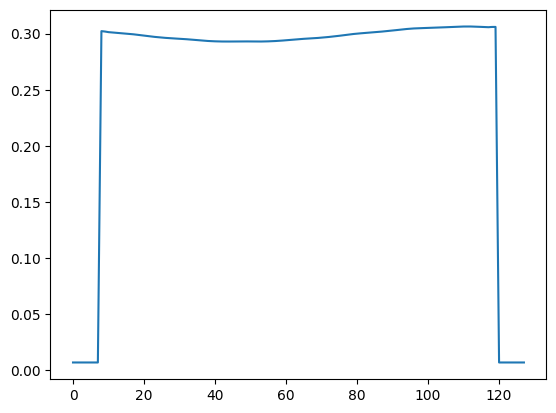

0.30638128557203476
(1, 128, 128, 4)


<function matplotlib.pyplot.show(close=None, block=None)>

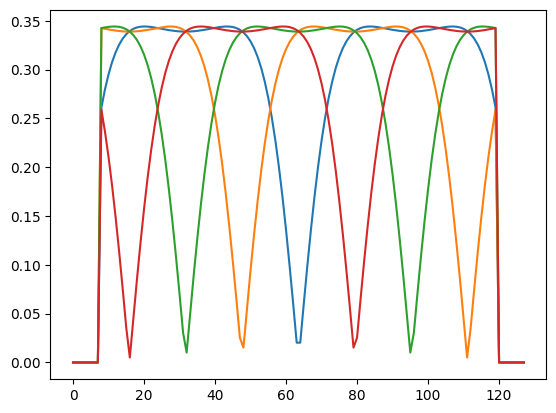

In [46]:
target2 = deepssfp.from_pairs_to_complex(ds.inputScaler.inverse_transform(ds2.y_test))
plt.plot(np.abs(target2[0,20,:]))
plt.show()

print(np.max(np.abs(target2[0,20,:])))

target2_ds = deepssfp.from_pairs_to_complex(ds.inputScaler.inverse_transform(ds2.x_test))
print(target2_ds.shape)
plt.plot(np.abs(target2_ds[0,20,:]))
plt.show

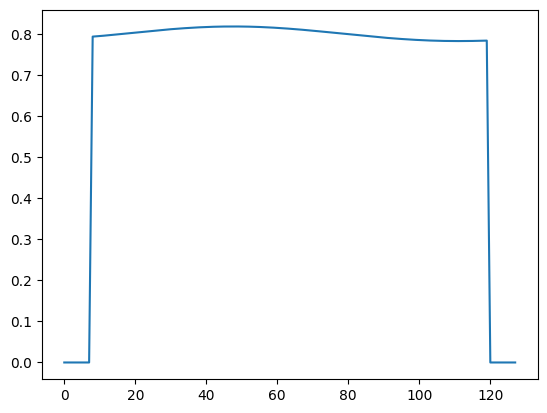

In [52]:
plt.plot(np.abs(target[0,20,:]) / np.abs(target2[0,20,:]))

(1, 128, 128, 4) (1, 128, 128, 4)


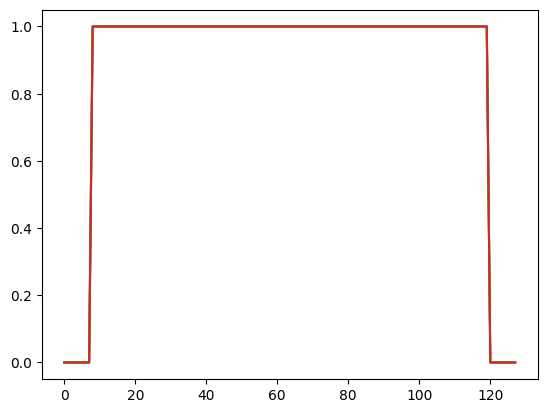

In [55]:
plt.plot(np.abs(target_ds[0,20,:]) / np.abs(target2_ds[0,20,:]))
print(target_ds.shape, target2_ds.shape)
plt.show()